In [16]:
import sqlite3, random, csv
from datetime import date, timedelta

random.seed(42)

conn = sqlite3.connect("bigbasket_capstone.db")
cur = conn.cursor()

cur.executescript("""
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS customers;
DROP TABLE IF EXISTS orders;
DROP TABLE IF EXISTS category_targets;

CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT NOT NULL,
    category TEXT NOT NULL,
    supplier TEXT NOT NULL,
    unit_price_inr INTEGER NOT NULL
);
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    signup_date TEXT NOT NULL,
    city TEXT NOT NULL
);
CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    order_date TEXT NOT NULL,
    quantity INTEGER NOT NULL,
    amount_inr INTEGER NOT NULL,
    payment_mode TEXT NOT NULL,
    status TEXT NOT NULL,
    rating INTEGER,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
);
CREATE TABLE category_targets (
    category TEXT PRIMARY KEY,
    target_revenue_inr INTEGER NOT NULL
);
""")

cities = ["Bengaluru", "Mumbai", "Hyderabad", "Pune"]

products_raw = [
    ("Banana 1kg", "Fruits & Vegetables", "FreshFarms Co", 50),
    ("Tomato 1kg", "Fruits & Vegetables", "FreshFarms Co", 40),
    ("Onion 1kg", "Fruits & Vegetables", "GreenValley Traders", 35),
    ("Apple 1kg", "Fruits & Vegetables", "GreenValley Traders", 180),
    ("Spinach Bunch", "Fruits & Vegetables", "FreshFarms Co", 25),
    ("Toned Milk 1L", "Dairy & Eggs", "DairyBest Ltd", 60),
    ("Paneer 200g", "Dairy & Eggs", "DairyBest Ltd", 90),
    ("Eggs (12pc)", "Dairy & Eggs", "CountryEggs Farms", 84),
    ("Curd 400g", "Dairy & Eggs", "DairyBest Ltd", 45),
    ("Butter 100g", "Dairy & Eggs", "CountryEggs Farms", 55),
    ("Potato Chips 90g", "Snacks & Beverages", "SnackHub India", 30),
    ("Cola 750ml", "Snacks & Beverages", "SnackHub India", 45),
    ("Biscuit Pack", "Snacks & Beverages", "BakeHouse Supplies", 35),
    ("Fruit Juice 1L", "Snacks & Beverages", "SnackHub India", 110),
    ("Namkeen 200g", "Snacks & Beverages", "BakeHouse Supplies", 60),
    ("Shampoo 340ml", "Personal Care", "CarePlus Distributors", 220),
    ("Toothpaste 150g", "Personal Care", "CarePlus Distributors", 95),
    ("Soap Bar 125g", "Personal Care", "CarePlus Distributors", 40),
    ("Hand Wash 250ml", "Personal Care", "CarePlus Distributors", 99),
    ("Face Wash 100g", "Personal Care", "CarePlus Distributors", 150),
    ("Dish Wash Bar", "Household Essentials", "HomeEssentials Traders", 20),
    ("Detergent 1kg", "Household Essentials", "HomeEssentials Traders", 130),
    ("Floor Cleaner 1L", "Household Essentials", "HomeEssentials Traders", 145),
    ("Toilet Cleaner 500ml", "Household Essentials", "HomeEssentials Traders", 89),
    ("Garbage Bags (30pc)", "Household Essentials", "HomeEssentials Traders", 75),
    ("Bread Loaf", "Bakery", "BakeHouse Supplies", 45),
    ("Croissant (2pc)", "Bakery", "BakeHouse Supplies", 70),
    ("Muffin Pack (4pc)", "Bakery", "BakeHouse Supplies", 120),
    ("Cake Slice", "Bakery", "BakeHouse Supplies", 85),
    ("Cookies 200g", "Bakery", "BakeHouse Supplies", 65),
    ("Premium Face Cream 50g", "Personal Care", "CarePlus Distributors", 450),
]
# Note: "Premium Face Cream 50g" (product_id 31) is deliberately excluded from
# popularity_weights/product_ids_weighted below, so it never receives an order —
# this gives the Task 4(b) LEFT JOIN a genuine zero-order row to preserve.
products = [(i, *p) for i, p in enumerate(products_raw, start=1)]
cur.executemany("INSERT INTO products VALUES (?,?,?,?,?)", products)

first_names = ["Aarav","Vivaan","Aditya","Vihaan","Arjun","Sai","Reyansh","Ayaan","Krishna","Ishaan",
               "Ananya","Diya","Saanvi","Aadhya","Kiara","Myra","Anika","Navya","Riya","Siya",
               "Rohan","Kabir","Dev","Yash","Aryan","Zara","Meera","Tara","Nisha","Priya",
               "Aman","Rahul","Karan","Varun","Nikhil","Pooja","Neha","Simran","Divya","Isha",
               "Rohit","Sanjay","Vikram","Manish","Deepak","Kavya","Shreya","Anjali","Pallavi","Sneha"]
customers = []
start_signup = date(2025, 1, 1)
for i, fname in enumerate(first_names, start=1):
    city = cities[i % len(cities)]
    signup = start_signup + timedelta(days=random.randint(0, 400))
    customers.append((i, fname, signup.isoformat(), city))
cur.executemany("INSERT INTO customers VALUES (?,?,?,?)", customers)

popularity_weights = [10,8,6,3,5, 9,7,6,8,4, 10,9,5,4,6, 3,5,9,4,3, 8,6,5,4,7, 6,4,3,5,4]
order_date_start = date(2026, 1, 1)
order_date_end = date(2026, 6, 30)
total_days = (order_date_end - order_date_start).days

TOTAL_ORDERS = 500
product_ids_weighted = []
for pid, w in zip(range(1, 31), popularity_weights):
    product_ids_weighted.extend([pid] * w)

payment_modes = ["UPI", "Credit Card", "Debit Card", "Cash on Delivery", "Wallet"]
product_lookup = {p[0]: p for p in products}
customer_lookup = {c[0]: c for c in customers}

orders = []
order_id = 1
for _ in range(TOTAL_ORDERS):
    cust_id = random.randint(1, 50)
    prod_id = random.choice(product_ids_weighted)
    unit_price = product_lookup[prod_id][4]
    quantity = random.randint(1, 5)
    amount = quantity * unit_price
    day_offset = random.randint(0, total_days)
    o_date = order_date_start + timedelta(days=day_offset)
    payment_mode = random.choice(payment_modes)
    roll = random.random()
    if roll < 0.85:
        status = "Delivered"
        rating = random.randint(1, 5)
    elif roll < 0.95:
        status = "Cancelled"
        rating = None
    else:
        status = "Pending"
        rating = None
    orders.append([order_id, cust_id, prod_id, o_date.isoformat(), quantity, amount, payment_mode, status, rating])
    order_id += 1
cur.executemany("INSERT INTO orders VALUES (?,?,?,?,?,?,?,?,?)", [tuple(o) for o in orders])

category_targets = [
    ("Fruits & Vegetables", 12000),
    ("Dairy & Eggs", 16500),
    ("Snacks & Beverages", 13000),
    ("Personal Care", 15500),
    ("Household Essentials", 17000),
    ("Bakery", 12000),
]
cur.executemany("INSERT INTO category_targets VALUES (?,?)", category_targets)

conn.commit()

# --- Raw exports for Part 4 (Python/Pandas) — deliberately messy, do not "fix" here ---
raw_rows = []
for o in orders:
    order_id, cust_id, prod_id, o_date, qty, amt, pm, status, rating = o
    cust = customer_lookup[cust_id]
    raw_rows.append({
        "order_id": order_id, "order_date": o_date, "customer_name": cust[1],
        "city": cust[3], "category": product_lookup[prod_id][2], "product_id": prod_id,
        "quantity": qty, "amount_inr": amt, "payment_mode": pm, "status": status,
        "rating": rating if rating is not None else "",
    })

rng2 = random.Random(7)
casing_idx = rng2.sample(range(len(raw_rows)), 20)
for idx in casing_idx:
    r = raw_rows[idx]
    variant = rng2.choice(["upper", "lower", "space"])
    r["city"] = r["city"].upper() if variant == "upper" else (r["city"].lower() if variant == "lower" else " " + r["city"] + " ")
    variant2 = rng2.choice(["upper", "lower", "space"])
    r["category"] = r["category"].upper() if variant2 == "upper" else (r["category"].lower() if variant2 == "lower" else " " + r["category"] + " ")

null_idx = rng2.sample([i for i in range(len(raw_rows)) if i not in casing_idx], 10)
for idx in null_idx:
    raw_rows[idx]["amount_inr"] = ""

outlier_pool = [i for i in range(len(raw_rows)) if i not in casing_idx and i not in null_idx]
outlier_idx = rng2.sample(outlier_pool, 5)
for idx in outlier_idx:
    raw_rows[idx]["amount_inr"] = raw_rows[idx]["amount_inr"] * 40

dup_pool = [i for i in range(len(raw_rows)) if i not in casing_idx and i not in null_idx and i not in outlier_idx]
dup_idx = rng2.sample(dup_pool, 8)
all_rows = raw_rows + [dict(raw_rows[i]) for i in dup_idx]

fieldnames = ["order_id","order_date","customer_name","city","category","product_id",
              "quantity","amount_inr","payment_mode","status","rating"]
with open("orders_raw.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(all_rows)

with open("products.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["product_id", "product_name", "category", "supplier", "unit_price_inr"])
    w.writerows(products)

conn.close()
print("bigbasket_capstone.db, orders_raw.csv, products.csv created.")


bigbasket_capstone.db, orders_raw.csv, products.csv created.


In [17]:
import pandas as pd

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("Number of orders:", len(orders))
print("Number of products:", len(products))
print("Number of customers:", orders["customer_id"].nunique())

print("\nOrder Status:")
print(orders["status"].value_counts())

print("\nTotal Revenue:")
print(orders["amount_inr"].sum())

Number of orders: 508
Number of products: 31


KeyError: 'customer_id'

In [22]:
print("Orders columns:")
print(orders.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

Orders columns:
['order_id', 'order_date', 'customer_name', 'city', 'category', 'product_id', 'quantity', 'amount_inr', 'payment_mode', 'status', 'rating']

Products columns:
['product_id', 'product_name', 'category', 'supplier', 'unit_price_inr']


In [23]:
print(orders.head())

   order_id  order_date customer_name       city              category  \
0         1  2026-03-09           Dev       Pune    Snacks & Beverages   
1         2  2026-05-22         Ayaan  Bengaluru    Snacks & Beverages   
2         3  2026-06-30          Yash  Bengaluru  Household Essentials   
3         4  2026-03-01         Sneha  Hyderabad    Snacks & Beverages   
4         5  2026-04-05         Rohit     Mumbai    Snacks & Beverages   

   product_id  quantity  amount_inr payment_mode     status  rating  
0          13         5       175.0          UPI  Delivered     5.0  
1          15         1        60.0   Debit Card  Delivered     5.0  
2          25         2       150.0          UPI  Delivered     2.0  
3          11         1        30.0          UPI  Delivered     4.0  
4          14         2       220.0   Debit Card  Delivered     3.0  


In [24]:
print("Total rows:", len(orders))

print("Number of unique customers:", orders["customer_name"].nunique())

print("\nOrder Status:")
print(orders["status"].value_counts())

print("\nTotal Revenue:")
print(orders["amount_inr"].sum())

Total rows: 508
Number of unique customers: 50

Order Status:
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

Total Revenue:
128250.0


In [25]:
import sqlite3

conn = sqlite3.connect("bigbasket_capstone.db")

orders_db = pd.read_sql_query("SELECT * FROM orders", conn)
products_db = pd.read_sql_query("SELECT * FROM products", conn)
customers_db = pd.read_sql_query("SELECT * FROM customers", conn)

print("Orders:", len(orders_db))
print("Products:", len(products_db))
print("Customers:", len(customers_db))

print("\nOrder Status:")
print(orders_db["status"].value_counts())

print("\nTotal Revenue:")
print(orders_db["amount_inr"].sum())

conn.close()

Orders: 500
Products: 31
Customers: 50

Order Status:
status
Delivered    434
Cancelled     42
Pending       24
Name: count, dtype: int64

Total Revenue:
102865


In [26]:
delivered_revenue = orders_db.loc[
    orders_db["status"] == "Delivered",
    "amount_inr"
].sum()

print("Delivered Revenue:", delivered_revenue)

Delivered Revenue: 88282


In [27]:
import sqlite3

conn = sqlite3.connect("bigbasket_capstone.db")

print("Database connected successfully!")

Database connected successfully!


In [28]:
cursor = conn.cursor()

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

tables = cursor.fetchall()

print("Tables in the database:")
for table in tables:
    print(table[0])

Tables in the database:
products
customers
orders
category_targets


In [29]:
query = """
SELECT *
FROM orders
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)

result

,order_id,customer_id,product_id,order_date,quantity,amount_inr,payment_mode,status,rating
0,1,23,13,2026-03-09,5,175,UPI,Delivered,5
1,2,8,15,2026-05-22,1,60,Debit Card,Delivered,5
2,3,24,25,2026-06-30,2,150,UPI,Delivered,2
3,4,50,11,2026-03-01,1,30,UPI,Delivered,4
4,5,41,14,2026-04-05,2,220,Debit Card,Delivered,3


In [30]:
query = """
SELECT order_id, order_date, quantity, amount_inr, status
FROM orders;
"""

result = pd.read_sql_query(query, conn)

result.head(10)

,order_id,order_date,quantity,amount_inr,status
0,1,2026-03-09,5,175,Delivered
1,2,2026-05-22,1,60,Delivered
2,3,2026-06-30,2,150,Delivered
3,4,2026-03-01,1,30,Delivered
4,5,2026-04-05,2,220,Delivered
5,6,2026-06-05,1,65,Delivered
6,7,2026-03-11,4,396,Delivered
7,8,2026-01-09,2,80,Delivered
8,9,2026-02-24,3,267,Delivered
9,10,2026-03-05,2,60,Delivered


In [31]:
query = """
SELECT order_id, order_date, amount_inr, status
FROM orders
WHERE status = 'Delivered';
"""

result = pd.read_sql_query(query, conn)

result.head(10)

,order_id,order_date,amount_inr,status
0,1,2026-03-09,175,Delivered
1,2,2026-05-22,60,Delivered
2,3,2026-06-30,150,Delivered
3,4,2026-03-01,30,Delivered
4,5,2026-04-05,220,Delivered
5,6,2026-06-05,65,Delivered
6,7,2026-03-11,396,Delivered
7,8,2026-01-09,80,Delivered
8,9,2026-02-24,267,Delivered
9,10,2026-03-05,60,Delivered


In [32]:
print("Number of delivered orders:", len(result))

Number of delivered orders: 434


In [33]:
query = """
SELECT DISTINCT payment_mode
FROM orders;
"""

result = pd.read_sql_query(query, conn)

result

,payment_mode
0,UPI
1,Debit Card
2,Credit Card
3,Wallet
4,Cash on Delivery


In [34]:
query = """
SELECT order_id, order_date, quantity, amount_inr, status
FROM orders
ORDER BY amount_inr DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,order_id,order_date,quantity,amount_inr,status
0,214,2026-01-15,5,1100,Delivered
1,396,2026-02-08,5,900,Delivered
2,232,2026-02-08,5,750,Delivered
3,288,2026-04-05,5,725,Delivered
4,152,2026-01-26,4,720,Cancelled
5,334,2026-03-26,4,720,Delivered
6,222,2026-03-28,3,660,Delivered
7,77,2026-06-02,5,650,Pending
8,234,2026-06-06,5,650,Delivered
9,487,2026-05-11,5,650,Delivered


In [35]:
query = """
SELECT
    order_id,
    amount_inr AS order_amount,
    status
FROM orders
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,order_id,order_amount,status
0,1,175,Delivered
1,2,60,Delivered
2,3,150,Delivered
3,4,30,Delivered
4,5,220,Delivered
5,6,65,Delivered
6,7,396,Delivered
7,8,80,Delivered
8,9,267,Delivered
9,10,60,Delivered


In [36]:
query = """
SELECT
    order_id,
    payment_mode,
    amount_inr,
    status
FROM orders
WHERE payment_mode IN ('UPI', 'Credit Card');
"""

result = pd.read_sql_query(query, conn)

result.head(10)

,order_id,payment_mode,amount_inr,status
0,1,UPI,175,Delivered
1,3,UPI,150,Delivered
2,4,UPI,30,Delivered
3,6,Credit Card,65,Delivered
4,11,Credit Card,300,Pending
5,12,UPI,80,Cancelled
6,18,Credit Card,168,Delivered
7,19,UPI,225,Delivered
8,21,Credit Card,20,Delivered
9,24,UPI,50,Delivered


In [37]:
query = """
SELECT
    order_id,
    amount_inr,
    status
FROM orders
WHERE amount_inr BETWEEN 100 AND 300;
"""

result = pd.read_sql_query(query, conn)

result.head(10)

,order_id,amount_inr,status
0,1,175,Delivered
1,3,150,Delivered
2,5,220,Delivered
3,9,267,Delivered
4,11,300,Pending
5,13,140,Delivered
6,14,300,Pending
7,16,120,Delivered
8,18,168,Delivered
9,19,225,Delivered


In [38]:
query = """
SELECT
    order_id,
    amount_inr,
    status
FROM orders
WHERE amount_inr NOT BETWEEN 100 AND 300;
"""

result = pd.read_sql_query(query, conn)

result.head(10)

,order_id,amount_inr,status
0,2,60,Delivered
1,4,30,Delivered
2,6,65,Delivered
3,7,396,Delivered
4,8,80,Delivered
5,10,60,Delivered
6,12,80,Cancelled
7,15,65,Delivered
8,17,450,Delivered
9,20,45,Cancelled


In [39]:
query = """
SELECT
    order_id,
    status,
    rating
FROM orders
WHERE rating IS NULL;
"""

result = pd.read_sql_query(query, conn)

result.head(10)

,order_id,status,rating
0,11,Pending,None
1,12,Cancelled,None
2,14,Pending,None
3,20,Cancelled,None
4,33,Cancelled,None
5,55,Cancelled,None
6,61,Cancelled,None
7,73,Cancelled,None
8,77,Pending,None
9,84,Cancelled,None


In [40]:
print("Rows with NULL rating:", len(result))

Rows with NULL rating: 66


In [41]:
sql_foundations = """
-- BigBasket Capstone Project
-- 01_foundations.sql
-- SQL Foundation Concepts

-- 1. SELECT
SELECT order_id, order_date, quantity, amount_inr, status
FROM orders;


-- 2. WHERE
SELECT order_id, order_date, amount_inr, status
FROM orders
WHERE status = 'Delivered';


-- 3. DISTINCT
SELECT DISTINCT payment_mode
FROM orders;


-- 4. ORDER BY + LIMIT
SELECT order_id, order_date, quantity, amount_inr, status
FROM orders
ORDER BY amount_inr DESC
LIMIT 10;


-- 5. Alias using AS
SELECT
    order_id,
    amount_inr AS order_amount,
    status
FROM orders
LIMIT 10;


-- 6. IN
SELECT
    order_id,
    payment_mode,
    amount_inr,
    status
FROM orders
WHERE payment_mode IN ('UPI', 'Credit Card');


-- 7. BETWEEN
SELECT
    order_id,
    amount_inr,
    status
FROM orders
WHERE amount_inr BETWEEN 100 AND 300;


-- 8. NOT BETWEEN
SELECT
    order_id,
    amount_inr,
    status
FROM orders
WHERE amount_inr NOT BETWEEN 100 AND 300;


-- 9. IS NULL
SELECT
    order_id,
    status,
    rating
FROM orders
WHERE rating IS NULL;
"""

with open("01_foundations.sql", "w") as file:
    file.write(sql_foundations)

print("01_foundations.sql created successfully!")

01_foundations.sql created successfully!


In [42]:
import os

print(os.path.exists("01_foundations.sql"))

True


In [43]:
query = """
SELECT
    p.category,
    COUNT(o.order_id) AS order_count,
    SUM(o.amount_inr) AS total_revenue,
    AVG(o.amount_inr) AS avg_revenue
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
WHERE o.status = 'Delivered'
GROUP BY p.category;
"""

result = pd.read_sql_query(query, conn)

result

,category,order_count,total_revenue,avg_revenue
0,Bakery,67,15410,230.000000
1,Dairy & Eggs,66,14090,213.484848
2,Fruits & Vegetables,73,9790,134.109589
3,Household Essentials,79,21715,274.873418
4,Personal Care,66,16382,248.212121
5,Snacks & Beverages,83,10895,131.265060


In [44]:
query = """
SELECT
    p.category,
    COUNT(o.order_id) AS order_count,
    SUM(o.amount_inr) AS total_revenue,
    AVG(o.amount_inr) AS avg_revenue
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
WHERE o.status = 'Delivered'
GROUP BY p.category
HAVING SUM(o.amount_inr) > 10000;
"""

result = pd.read_sql_query(query, conn)

result

,category,order_count,total_revenue,avg_revenue
0,Bakery,67,15410,230.000000
1,Dairy & Eggs,66,14090,213.484848
2,Household Essentials,79,21715,274.873418
3,Personal Care,66,16382,248.212121
4,Snacks & Beverages,83,10895,131.265060


In [45]:
query = """
SELECT
    p.product_name,
    p.category,
    COUNT(o.order_id) AS order_count
FROM products AS p
LEFT JOIN orders AS o
    ON p.product_id = o.product_id
GROUP BY
    p.product_id,
    p.product_name,
    p.category
ORDER BY order_count ASC;
"""

result = pd.read_sql_query(query, conn)

result

,product_name,category,order_count
0,Premium Face Cream 50g,Personal Care,0
1,Shampoo 340ml,Personal Care,3
2,Apple 1kg,Fruits & Vegetables,6
3,Fruit Juice 1L,Snacks & Beverages,7
4,Face Wash 100g,Personal Care,7
5,Eggs (12pc),Dairy & Eggs,8
6,Butter 100g,Dairy & Eggs,12
7,Hand Wash 250ml,Personal Care,12
8,Banana 1kg,Fruits & Vegetables,14
9,Namkeen 200g,Snacks & Beverages,14


In [46]:
sql_aggregation = """
-- BigBasket Capstone Project
-- 02_aggregation_joins.sql
-- Aggregation and JOIN Queries


-- 1. INNER JOIN: Category-level delivered revenue
SELECT
    p.category,
    COUNT(o.order_id) AS order_count,
    SUM(o.amount_inr) AS total_revenue,
    AVG(o.amount_inr) AS avg_revenue
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
WHERE o.status = 'Delivered'
GROUP BY p.category;


-- 2. HAVING: Categories with revenue greater than ₹10,000
SELECT
    p.category,
    COUNT(o.order_id) AS order_count,
    SUM(o.amount_inr) AS total_revenue,
    AVG(o.amount_inr) AS avg_revenue
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
WHERE o.status = 'Delivered'
GROUP BY p.category
HAVING SUM(o.amount_inr) > 10000;


-- 3. LEFT JOIN: All products including zero-order products
SELECT
    p.product_name,
    p.category,
    COUNT(o.order_id) AS order_count
FROM products AS p
LEFT JOIN orders AS o
    ON p.product_id = o.product_id
GROUP BY
    p.product_id,
    p.product_name,
    p.category
ORDER BY order_count ASC;
"""

with open("02_aggregation_joins.sql", "w") as file:
    file.write(sql_aggregation)

print("02_aggregation_joins.sql created successfully!")

02_aggregation_joins.sql created successfully!


In [19]:
import os

print(os.path.exists("02_aggregation_joins.sql"))

True


In [47]:
query = "SELECT * FROM category_targets;"
result = pd.read_sql_query(query, conn)

result

,category,target_revenue_inr
0,Fruits & Vegetables,12000
1,Dairy & Eggs,16500
2,Snacks & Beverages,13000
3,Personal Care,15500
4,Household Essentials,17000
5,Bakery,12000


In [48]:
query = """

SELECT

    category,

    target_revenue_inr,

    CASE

        WHEN target_revenue_inr >= 15000 THEN 'High Target'

        WHEN target_revenue_inr >= 10000 THEN 'Medium Target'

        ELSE 'Low Target'

    END AS target_tier

FROM category_targets;

"""

result = pd.read_sql_query(query, conn)

result

,category,target_revenue_inr,target_tier
0,Fruits & Vegetables,12000,Medium Target
1,Dairy & Eggs,16500,High Target
2,Snacks & Beverages,13000,Medium Target
3,Personal Care,15500,High Target
4,Household Essentials,17000,High Target
5,Bakery,12000,Medium Target


In [49]:
sql_reporting = """
-- BigBasket Capstone Project
-- 03_reporting.sql
-- Reporting Queries


-- 1. CASE: Category target performance tier
SELECT
    category,
    target_revenue,
    CASE
        WHEN target_revenue >= 15000 THEN 'High Target'
        WHEN target_revenue >= 10000 THEN 'Medium Target'
        ELSE 'Low Target'
    END AS target_tier
FROM category_targets;


-- 2. Monthly category revenue report
-- Delivered orders only
SELECT
    p.category,
    strftime('%Y-%m', o.order_date) AS month,
    COUNT(o.order_id) AS order_count,
    SUM(o.amount_inr) AS total_revenue,
    AVG(o.amount_inr) AS avg_revenue
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
WHERE o.status = 'Delivered'
GROUP BY
    p.category,
    strftime('%Y-%m', o.order_date)
ORDER BY
    month,
    p.category;


-- 3. Category variance against target
SELECT
    p.category,
    SUM(o.amount_inr) AS actual_revenue,
    t.target_revenue,
    SUM(o.amount_inr) - t.target_revenue AS variance,
    ROUND(
        (SUM(o.amount_inr) - t.target_revenue) * 100.0
        / t.target_revenue,
        2
    ) AS percentage_variance
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
INNER JOIN category_targets AS t
    ON p.category = t.category
WHERE o.status = 'Delivered'
GROUP BY
    p.category,
    t.target_revenue
ORDER BY
    p.category;
"""

with open("03_reporting.sql", "w") as file:
    file.write(sql_reporting)

print("03_reporting.sql created successfully!")

03_reporting.sql created successfully!


In [50]:
import os

print(os.path.exists("03_reporting.sql"))

True


In [51]:
monthly_query = """
SELECT
    p.category,
    strftime('%Y-%m', o.order_date) AS month,
    COUNT(o.order_id) AS order_count,
    SUM(o.amount_inr) AS total_revenue,
    AVG(o.amount_inr) AS avg_revenue
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
WHERE o.status = 'Delivered'
GROUP BY
    p.category,
    strftime('%Y-%m', o.order_date)
ORDER BY
    p.category,
    month;
"""

monthly_data = pd.read_sql_query(monthly_query, conn)

monthly_data.to_csv("monthly_category_revenue.csv", index=False)

print("monthly_category_revenue.csv created successfully!")

monthly_category_revenue.csv created successfully!


In [52]:
print("Rows:", len(monthly_data))
print("Total Revenue:", monthly_data["total_revenue"].sum())
print("\nColumns:")
print(list(monthly_data.columns))

Rows: 36
Total Revenue: 88282

Columns:
['category', 'month', 'order_count', 'total_revenue', 'avg_revenue']


In [53]:
from google.colab import files

files.download("monthly_category_revenue.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
import pandas as pd

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("Orders shape:", orders.shape)
print("Products shape:", products.shape)

Orders shape: (508, 11)
Products shape: (31, 5)


In [55]:
print("ORDERS DATA")
display(orders.head())

print("\nORDERS COLUMNS:")
print(orders.columns.tolist())

print("\nPRODUCTS DATA")
display(products.head())

print("\nPRODUCTS COLUMNS:")
print(products.columns.tolist())

ORDERS DATA


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0



ORDERS COLUMNS:
['order_id', 'order_date', 'customer_name', 'city', 'category', 'product_id', 'quantity', 'amount_inr', 'payment_mode', 'status', 'rating']

PRODUCTS DATA


,product_id,product_name,category,supplier,unit_price_inr
0,1,Banana 1kg,Fruits & Vegetables,FreshFarms Co,50
1,2,Tomato 1kg,Fruits & Vegetables,FreshFarms Co,40
2,3,Onion 1kg,Fruits & Vegetables,GreenValley Traders,35
3,4,Apple 1kg,Fruits & Vegetables,GreenValley Traders,180
4,5,Spinach Bunch,Fruits & Vegetables,FreshFarms Co,25



PRODUCTS COLUMNS:
['product_id', 'product_name', 'category', 'supplier', 'unit_price_inr']


In [56]:
print("Dataset information:")
orders.info()

print("\nDescriptive statistics:")
display(orders.describe())

print("\nOrder status counts:")
print(orders["status"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB

Descriptive statistics:


,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000



Order status counts:
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64


In [57]:
print("Number of duplicate rows:", orders.duplicated().sum())

print("Number of duplicate order IDs:", orders["order_id"].duplicated().sum())

print("\nDuplicate order IDs:")
print(orders.loc[orders["order_id"].duplicated(keep=False), "order_id"].unique())

Number of duplicate rows: 8
Number of duplicate order IDs: 8

Duplicate order IDs:
[ 50 102 136 139 165 389 433 440]


In [58]:
orders = orders.drop_duplicates(subset="order_id", keep="first").copy()

print("Rows after removing duplicates:", len(orders))
print("Unique order IDs:", orders["order_id"].nunique())

Rows after removing duplicates: 500
Unique order IDs: 500


In [60]:
orders["city"] = orders["city"].str.strip().str.title()
orders["category"] = orders["category"].str.strip().str.title()

print("Unique cities:", orders["city"].nunique())
print(orders["city"].unique())

print("\nUnique categories:", orders["category"].nunique())
print(orders["category"].unique())

Unique cities: 4
['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai']

Unique categories: 6
['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs']


In [61]:
missing_amount = orders["amount_inr"].isna().sum()

print("Missing amount_inr values:", missing_amount)

Missing amount_inr values: 10


In [62]:
print(orders.groupby("status")["rating"].apply(lambda x: x.isna().sum()))

status
Cancelled    42
Delivered     0
Pending      24
Name: rating, dtype: int64


In [63]:
delivered_amounts = orders.loc[
    orders["status"] == "Delivered", "amount_inr"
].dropna()

Q1 = delivered_amounts.quantile(0.25)
Q3 = delivered_amounts.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper fence:", upper_fence)

Q1: 90.0
Q3: 275.0
IQR: 185.0
Upper fence: 552.5


In [64]:
outliers = orders[
    (orders["status"] == "Delivered") &
    (orders["amount_inr"] > upper_fence)
]

print("Number of delivered revenue outliers:", len(outliers))

print("\nOutlier amounts:")
print(outliers["amount_inr"].tolist())

Number of delivered revenue outliers: 16

Outlier amounts:
[600.0, 580.0, 580.0, 580.0, 600.0, 600.0, 5400.0, 1100.0, 660.0, 650.0, 5200.0, 7600.0, 720.0, 600.0, 900.0, 650.0]


In [65]:
orders.loc[orders["status"] == "Delivered", "amount_inr"] = (
    orders.loc[orders["status"] == "Delivered", "amount_inr"]
    .clip(upper=upper_fence)
)

print("Maximum delivered amount after capping:",
      orders.loc[orders["status"] == "Delivered", "amount_inr"].max())

Maximum delivered amount after capping: 552.5


In [66]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders["month"] = orders["order_date"].dt.to_period("M").astype(str)

orders["month_name"] = orders["order_date"].dt.month_name()

orders["revenue_per_unit"] = orders["amount_inr"] / orders["quantity"]

orders["is_delivered"] = orders["status"].eq("Delivered")

display(orders.head())

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating,month,month_name,revenue_per_unit,is_delivered
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0,2026-03,March,35.0,True
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0,2026-05,May,60.0,True
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0,2026-06,June,75.0,True
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0,2026-03,March,30.0,True
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0,2026-04,April,110.0,True


In [67]:
delivered = orders[orders["is_delivered"]].copy()

category_revenue = (
    delivered.groupby("category", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=False)
)

display(category_revenue)

,category,amount_inr
3,Household Essentials,20910.0
0,Bakery,14975.0
4,Personal Care,14594.5
1,Dairy & Eggs,13675.0
5,Snacks & Beverages,11312.5
2,Fruits & Vegetables,9170.0


In [68]:
orders_products = orders.merge(
    products[["product_id", "product_name", "supplier", "unit_price_inr"]],
    on="product_id",
    how="left"
)

supplier_revenue = (
    orders_products[orders_products["is_delivered"]]
    .groupby("supplier", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=False)
)

display(supplier_revenue.head())

,supplier,amount_inr
6,HomeEssentials Traders,20910.0
0,BakeHouse Supplies,18550.0
1,CarePlus Distributors,14594.5
3,DairyBest Ltd,10710.0
7,SnackHub India,7737.5


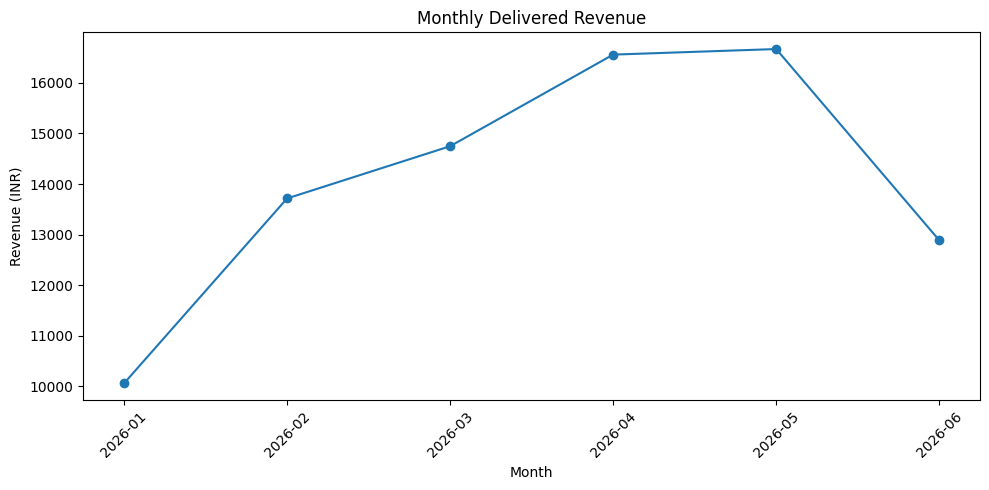

In [69]:
# Monthly Delivered Revenue

import matplotlib.pyplot as plt

monthly_revenue = (
    delivered.groupby("month", as_index=False)["amount_inr"]
    .sum()
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue["month"], monthly_revenue["amount_inr"], marker="o")
plt.title("Monthly Delivered Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

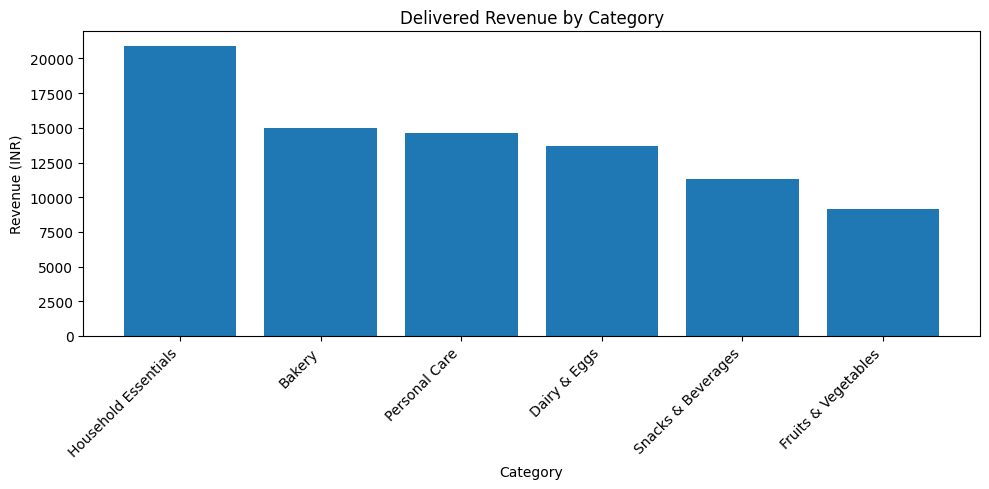

In [70]:
# Category Revenue Chart
plt.figure(figsize=(10, 5))

plt.bar(
    category_revenue["category"],
    category_revenue["amount_inr"]
)

plt.title("Delivered Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

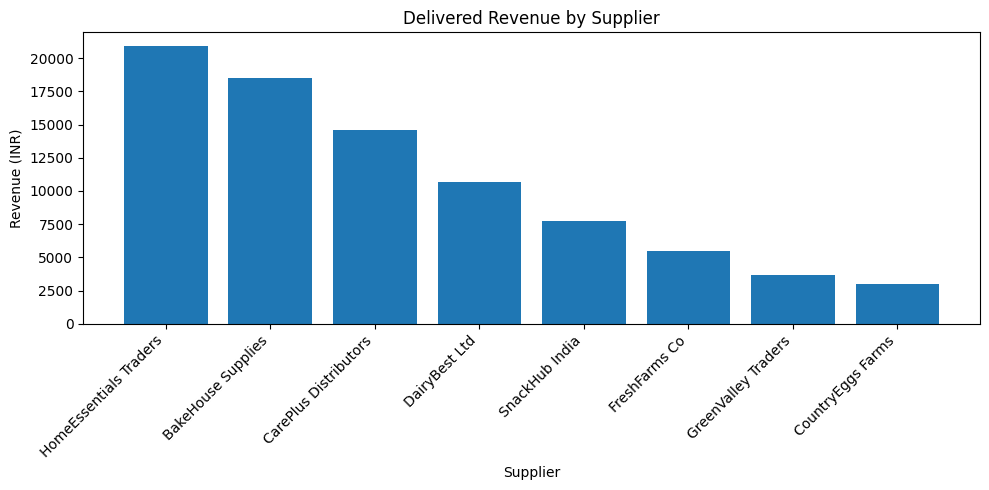

In [71]:
# Supplier Revenue Chart

plt.figure(figsize=(10, 5))

plt.bar(
    supplier_revenue["supplier"],
    supplier_revenue["amount_inr"]
)

plt.title("Delivered Revenue by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Observation 1 — Monthly Revenue Trend

What: Delivered revenue increased from about ₹10,050 in January to about ₹16,650 in May, before falling to about ₹12,900 in June.

Why: Revenue strengthened through April and May but declined noticeably in June, suggesting a need to investigate the causes of the monthly slowdown.

Next Step: Compare June with earlier months by category and product to identify which areas contributed most to the decline.


Observation 2 — Category Performance

What: Household Essentials generated the highest cleaned delivered revenue at ₹20,910, while Fruits & Vegetables generated the lowest at ₹9,170.

Why: Household Essentials is the strongest revenue category, whereas Fruits & Vegetables is contributing substantially less revenue.

Next Step: Investigate product-level performance in Fruits & Vegetables and consider promotions or assortment improvements to increase its revenue.


Observation 3 — Supplier Performance

What: HomeEssentials Traders generated the highest delivered revenue at ₹20,910, followed by BakeHouse Supplies at ₹18,550.

Why: These suppliers are associated with strong revenue-generating categories and products in the cleaned dataset.

Next Step: Review the products supplied by the top suppliers and use their performance to guide inventory and supplier planning.


RCTCF AI Prompt #2 — Pandas Analysis

Role: You are a senior data analyst helping a beginner complete a Pandas data-cleaning and analysis task.

Context: I am analyzing BigBasket order data using Python and Pandas. The raw orders CSV contains duplicate order IDs, inconsistent city/category formatting, missing amount values, and extreme delivered-order revenue outliers.

Task: Help me clean and analyze the data using Pandas. The workflow should:
1. Load orders_raw.csv and products.csv.
2. Inspect the data using info(), describe(), and status value counts before modifying it.
3. Check and remove duplicate order IDs while keeping the first occurrence.
4. Standardize city and category using strip() and title().
5. Count missing amount_inr values without filling them.
6. Calculate the IQR and upper fence for delivered non-null amount_inr values.
7. Cap delivered revenue outliers at the upper fence instead of deleting them.
8. Create month, month_name, revenue_per_unit, and is_delivered columns.
9. Calculate delivered revenue by category.
10. Merge product information and calculate delivered revenue by supplier.
11. Create three appropriate Matplotlib charts.
12. Provide exactly three What/Why/Next-step observations.

Verification requirements:
- Confirm that duplicate removal results in exactly 500 rows and 500 unique order IDs.
- Confirm that there are exactly 4 cities and 6 categories after cleaning.
- Confirm that there are exactly 10 missing amount_inr values.
- Confirm that the delivered amount IQR is Q1 = ₹90, Q3 = ₹275, IQR = ₹185, and upper fence = ₹552.50.
- Confirm that exactly 16 delivered revenue values are above the upper fence before capping.
- Confirm that the maximum delivered amount after capping is ₹552.50.
- Confirm that Household Essentials is the highest-revenue category.
- Confirm that HomeEssentials Traders is the highest-revenue supplier.
- Do not modify the raw CSV file.

# AI Prompting Log

## RCTCF AI Prompt #1 — SQL Diagnostic

Role: You are a senior SQL data analyst helping a beginner analyze BigBasket order data.

Context: The dataset contains orders, products, customers, and category targets. The goal is to perform data validation, aggregation, joins, reporting, and category target analysis using SQLite.

Task: Help create SQL queries for data validation, delivered revenue analysis, category performance, product order counts, CASE-based performance tiers, monthly category revenue, and variance against category targets.

Constraints: Use SQLite-compatible SQL. Explain queries clearly and avoid changing the source data.

Verification: Confirm expected values such as 500 orders, 31 products, 50 customers, 434 delivered orders, and ₹88,282 delivered revenue.

---

## RCTCF AI Prompt #2 — Pandas Analysis

Role: You are a senior data analyst helping a beginner complete a Pandas data-cleaning and analysis task.

Context: I am analyzing BigBasket order data using Python and Pandas. The raw orders CSV contains duplicate order IDs, inconsistent city/category formatting, missing amount values, and extreme delivered-order revenue outliers.

Task: Help me clean and analyze the data using Pandas. The workflow should:
1. Load orders_raw.csv and products.csv.
2. Inspect the data using info(), describe(), and status value counts before modifying it.
3. Check and remove duplicate order IDs while keeping the first occurrence.
4. Standardize city and category using strip() and title().
5. Count missing amount_inr values without filling them.
6. Calculate the IQR and upper fence for delivered non-null amount_inr values.
7. Cap delivered revenue outliers at the upper fence instead of deleting them.
8. Create month, month_name, revenue_per_unit, and is_delivered columns.
9. Calculate delivered revenue by category.
10. Merge product information and calculate delivered revenue by supplier.
11. Create three appropriate Matplotlib charts.
12. Provide exactly three What/Why/Next-step observations.

Verification:
- Confirm that duplicate removal results in exactly 500 rows and 500 unique order IDs.
- Confirm that there are exactly 4 cities and 6 categories after cleaning.
- Confirm that there are exactly 10 missing amount_inr values.
- Confirm that the delivered amount IQR is Q1 = ₹90, Q3 = ₹275, IQR = ₹185, and upper fence = ₹552.50.
- Confirm that exactly 16 delivered revenue values are above the upper fence before capping.
- Confirm that the maximum delivered amount after capping is ₹552.50.
- Confirm that Household Essentials is the highest-revenue category.
- Confirm that HomeEssentials Traders is the highest-revenue supplier.
- Do not modify the raw CSV file.

In [72]:
ai_log = """# AI Prompting Log

## RCTCF AI Prompt #1 — SQL Diagnostic

Role: You are a senior SQL data analyst helping a beginner analyze BigBasket order data.

Context: The dataset contains orders, products, customers, and category targets. The goal is to perform data validation, aggregation, joins, reporting, and category target analysis using SQLite.

Task: Help create SQL queries for data validation, delivered revenue analysis, category performance, product order counts, CASE-based performance tiers, monthly category revenue, and variance against category targets.

Constraints: Use SQLite-compatible SQL. Explain queries clearly and avoid changing the source data.

Verification: Confirm expected values such as 500 orders, 31 products, 50 customers, 434 delivered orders, and ₹88,282 delivered revenue.

---

## RCTCF AI Prompt #2 — Pandas Analysis

Role: You are a senior data analyst helping a beginner complete a Pandas data-cleaning and analysis task.

Context: I am analyzing BigBasket order data using Python and Pandas. The raw orders CSV contains duplicate order IDs, inconsistent city/category formatting, missing amount values, and extreme delivered-order revenue outliers.

Task: Help me clean and analyze the data using Pandas. The workflow should:
1. Load orders_raw.csv and products.csv.
2. Inspect the data using info(), describe(), and status value counts before modifying it.
3. Check and remove duplicate order IDs while keeping the first occurrence.
4. Standardize city and category using strip() and title().
5. Count missing amount_inr values without filling them.
6. Calculate the IQR and upper fence for delivered non-null amount_inr values.
7. Cap delivered revenue outliers at the upper fence instead of deleting them.
8. Create month, month_name, revenue_per_unit, and is_delivered columns.
9. Calculate delivered revenue by category.
10. Merge product information and calculate delivered revenue by supplier.
11. Create three appropriate Matplotlib charts.
12. Provide exactly three What/Why/Next-step observations.

Verification:
- Confirm that duplicate removal results in exactly 500 rows and 500 unique order IDs.
- Confirm that there are exactly 4 cities and 6 categories after cleaning.
- Confirm that there are exactly 10 missing amount_inr values.
- Confirm that the delivered amount IQR is Q1 = ₹90, Q3 = ₹275, IQR = ₹185, and upper fence = ₹552.50.
- Confirm that exactly 16 delivered revenue values are above the upper fence before capping.
- Confirm that the maximum delivered amount after capping is ₹552.50.
- Confirm that Household Essentials is the highest-revenue category.
- Confirm that HomeEssentials Traders is the highest-revenue supplier.
- Do not modify the raw CSV file.
"""

with open("ai_log.md", "w", encoding="utf-8") as f:
    f.write(ai_log)

print("ai_log.md created successfully!")

ai_log.md created successfully!
